### 1. Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Flatten, Dense

### 2. Load CIFAR-10 dataset

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

### 3. Check the dataset

In [3]:
print("Training data:", X_train.shape)
print("Training labels:", y_train.shape)

print("\nTesting data:", X_test.shape)
print("Testing labels:", y_test.shape)

Training data: (50000, 32, 32, 3)
Training labels: (50000, 1)

Testing data: (10000, 32, 32, 3)
Testing labels: (10000, 1)


### 4. Define CIFAR-10 class names

In [4]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

### 5. Display one image

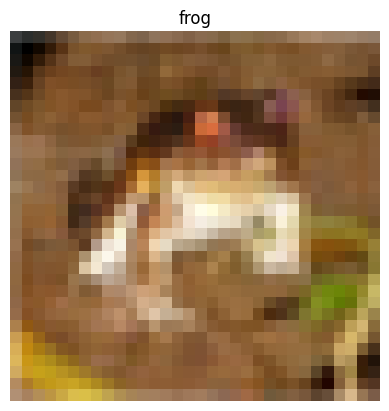

In [5]:
plt.imshow(X_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis("off")
plt.show()

### 6. Normalize the images

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### 7. Build the ANN model

In [7]:
model = Sequential()

model.add(Flatten(input_shape=(32, 32, 3)))
model.add(Dense(1024, activation="relu"))
model.add(Dense(512, activation="relu"))
model.add(Dense(256, activation="relu"))
model.add(Dense(10, activation="softmax"))

### 8. Check the model

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 3072)              0         
                                                                 
 dense (Dense)               (None, 1024)              3146752   
                                                                 
 dense_1 (Dense)             (None, 512)               524800    
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dense_3 (Dense)             (None, 10)                2570      
                                                                 
Total params: 3,805,450
Trainable params: 3,805,450
Non-trainable params: 0
_________________________________________________________________


### 9. Compile the model

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### 10. Train the model || 11. Evaluate the model

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/20
1250/1250 [==============================] - 38s 30ms/step - loss: 1.8872 - accuracy: 0.3162 - val_loss: 1.8207 - val_accuracy: 0.3467
Epoch 2/20
1250/1250 [==============================] - 41s 32ms/step - loss: 1.7098 - accuracy: 0.3818 - val_loss: 1.6564 - val_accuracy: 0.4078
Epoch 3/20
1250/1250 [==============================] - 83s 67ms/step - loss: 1.6181 - accuracy: 0.4142 - val_loss: 1.6906 - val_accuracy: 0.3963
Epoch 4/20
1250/1250 [==============================] - 85s 68ms/step - loss: 1.5646 - accuracy: 0.4387 - val_loss: 1.6069 - val_accuracy: 0.4213
Epoch 5/20
1250/1250 [==============================] - 88s 70ms/step - loss: 1.5148 - accuracy: 0.4541 - val_loss: 1.5358 - val_accuracy: 0.4507
Epoch 6/20
1250/1250 [==============================] - 68s 55ms/step - loss: 1.4821 - accuracy: 0.4665 - val_loss: 1.5478 - val_accuracy: 0.4543
Epoch 7/20
1250/1250 [==============================] - 77s 62ms/step - loss: 1.4443 - accuracy: 0.4760 - val_loss: 1.5168 -

### 12. Model predictions

In [11]:
y_pred = model.predict(X_test)

313/313 [==============================] - 2s 6ms/step


In [12]:
prediction = np.argmax(y_pred[0])

print("Predicted class:", prediction)
print("Predicted label:", class_names[prediction])

Predicted class: 5
Predicted label: dog


In [13]:
actual = y_test[0][0]

print("Predicted:", class_names[prediction])
print("Actual:", class_names[actual])

Predicted: dog
Actual: cat


### 13. Display the image with prediction

Predicted: horse
Actual: deer


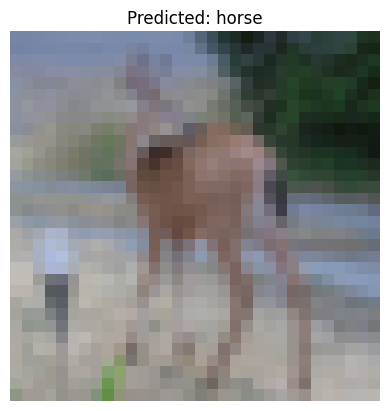

In [14]:
index = 100

prediction = np.argmax(y_pred[index])
actual = y_test[index][0]

print("Predicted:", class_names[prediction])
print("Actual:", class_names[actual])

plt.imshow(X_test[index])
plt.title(f"Predicted: {class_names[prediction]}")
plt.axis("off")
plt.show()